# 🚀 미니프로젝트 1 — 분류: MNIST·Fashion-MNIST를 CNN으로 + Streamlit 배포 💡

**여러분의 과제 시간입니다.** 1~10강에서 배운 것만으로 이미지 분류기를 만들고, validation으로 손잡이를 탐색한 뒤, 마지막에 test를 딱 한 번 열어 최종 성능을 확인합니다. 완성 모델은 웹앱으로 배포해 **우리 반 리더보드**에서 서로의 기록을 비교합니다.

| 구분 | 내용 | 제출물 |
|---|---|---|
| **1차 (필수)** | MNIST CNN — 전처리·훈련·**validation 실험 3개 이상**·최종 test 1회 | 이 노트북 |
| **2차 (필수)** | 같은 코드로 Fashion-MNIST — 별도 validation + 오답 확인 | 이 노트북 |
| **3차 (필수)** | 분류 앱 핵심 TODO 4개 완성 + Streamlit 연결 | 통합 showcase URL |
| 🏆 **리더보드 (필수)** | validation으로 고른 모델의 최종 test 기록 공유 | 제출 양식 1행 |
| 🏅 **도전 (선택)** | CIFAR-10 — 컬러 3채널로 확장 | 이 노트북 |

> **선수지식**: 3강(첫 신경망)·8강(학습 루프)·9강(일반화)·10강(분류 심화)이면 충분합니다. CNN 층의 설계 원리는 12강에서 배웁니다.
>
> **시험지 봉인 규칙**: 모델과 설정은 validation 결과로 고릅니다. test를 본 뒤 설정을 바꾸면 그 test도 사실상 validation이 되므로, 최종 test는 모델 선택이 끝난 뒤 1회만 사용합니다.

> ✍️ **직접 입력** 표시가 있는 줄은 바로 위 주석의 코드를 보고 직접 타이핑해 완성합니다.

**평가 기준** — ① TODO·✍️ 전부 완성 + 실행 결과 ② validation 실험 **3개 이상**과 기록 ③ 최종 test 1회 ④ 앱 핵심 TODO 4개 완성 ⑤ 통합 showcase 연결 ⑥ 리더보드 제출 1행


## 🔑 이 과제의 핵심 스캐폴딩 — 처음 만나는 함수들

| 함수/클래스 | 역할 | 등장 |
|---|---|---|
| `nn.Conv2d(입력채널, 출력채널, kernel_size)` | 작은 필터로 이미지의 지역 패턴 탐색 | [Step 3] |
| `nn.MaxPool2d(2)` | 2×2 구역의 최대값만 남겨 절반 크기로 요약 | [Step 3] |
| `nn.Flatten()` | `(N, 채널, 높이, 너비)` → `(N, 한 줄)`로 펴서 Linear에 연결 | [Step 3] |
| `torch.save(체크포인트, 경로)` | 가중치·구조 설정·성능 지표를 함께 저장 | [Step 7] |
| `keras.datasets.fashion_mnist` | MNIST와 같은 형식의 의류 이미지 | [Step 8] |

> **📐 이 과제의 계약 6줄**
> 1. 입력: `(N, 1, 28, 28)` float32, 값 0~1
> 2. 원래 train 60,000장을 **fit 50,000 + validation 10,000**으로 분리
> 3. 모델 출력: 로짓 `(N, 10)` — softmax 없음
> 4. 정답: 정수 라벨 `(N,)`, dtype `long`
> 5. 손실: `nn.CrossEntropyLoss()(로짓, 정수라벨)`
> 6. 모델 선택은 validation, 최종 보고만 test 10,000장


In [6]:
# ── 실행 준비 (로컬 · Colab · Kaggle 어디서나) ──
# [왜] 이 과제에 필요한 라이브러리를 환경에 맞게 준비하고, 연산 장치(device)를 자동 선택합니다.
# [연결] 이 셀의 device 로직은 1강 Solo에서 여러분이 직접 만든 '내 환경 설정'의 자동 감지 버전입니다.
import sys, os, importlib.util

# 1) 실행 환경 감지
if 'google.colab' in sys.modules:      ENV = "Colab"
elif os.path.exists('/kaggle/input'):  ENV = "Kaggle"
else:                                  ENV = "로컬"

# 2) 이 과제가 쓰는 라이브러리 점검 (없으면 설치 안내)
NEED = [("torch","torch"), ("keras","keras"), ("matplotlib","matplotlib")]
missing = [pip for imp, pip in NEED if importlib.util.find_spec(imp.split(".")[0]) is None]
if missing:
    bang = "" if ENV == "로컬" else "!"
    print(f"[{ENV}] 아래를 실행해 설치하세요:  {bang}pip install " + " ".join(missing))
else:
    print(f"[{ENV}] 라이브러리 준비 완료")

# 3) 연산 장치 자동 선택 (Apple MPS > NVIDIA CUDA > CPU)
import torch
DEVICE = torch.device("mps" if torch.backends.mps.is_available()
                      else "cuda" if torch.cuda.is_available() else "cpu")
print(f"DEVICE = {DEVICE}")

# 4) 한글 그래프 폰트 (OS 자동 — 그래프 제목·라벨 깨짐 방지)
import matplotlib.pyplot as plt, platform
import matplotlib.font_manager as fm
if platform.system() == "Darwin":      plt.rcParams['font.family'] = ['AppleGothic', 'DejaVu Sans']
elif platform.system() == "Windows":   plt.rcParams['font.family'] = ['Malgun Gothic', 'DejaVu Sans']
else:                                  # 리눅스(Colab·Kaggle): 나눔고딕이 없으면 설치 후 즉시 등록
    if not any(f.name == 'NanumGothic' for f in fm.fontManager.ttflist):
        os.system("apt-get -qq -y install fonts-nanum > /dev/null 2>&1")   # Colab 기본 이미지엔 한글 폰트가 없음
        for _fp in fm.findSystemFonts(fontpaths=['/usr/share/fonts/truetype/nanum']):
            fm.fontManager.addfont(_fp)                                    # 설치한 폰트를 재시작 없이 등록
    plt.rcParams['font.family'] = ['NanumGothic', 'DejaVu Sans']   # 리스트 = 폴백 체인(기호는 DejaVu 보완)
plt.rcParams['axes.unicode_minus'] = False

[로컬] 라이브러리 준비 완료
DEVICE = mps


## 1차 과제 (필수) — MNIST를 CNN으로

3강에서 Dense(Linear)만으로 97~98%를 얻었습니다. **같은 문제를 CNN으로 풀면 얼마나 오를까요?** 직접 확인합니다.

진행 순서: [Step 1] 데이터 로드 → [Step 2] 전처리(TODO) → [Step 3] CNN 모델(제공) → [Step 4] 훈련 루프(TODO) → [Step 5] 평가 → [Step 6] **손잡이 탐색 실험**(TODO) → [Step 7] 저장

In [7]:
# [Step 1] MNIST 로드 — 3강과 동일한 keras 직접 호출 (제공)
import os
os.environ.setdefault("KERAS_BACKEND", "torch")   # tensorflow 없이 keras만 설치돼 있어도 동작
import keras

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
print(f"훈련: {x_train.shape}, 테스트: {x_test.shape}")   # (60000, 28, 28) / (10000, 28, 28)
print(f"픽셀 값 범위: {x_train.min()} ~ {x_train.max()}")  # 0 ~ 255 정수

훈련: (60000, 28, 28), 테스트: (10000, 28, 28)
픽셀 값 범위: 0 ~ 255


shape : (60000, 28, 28) · dtype: uint8
값 범위: 0 ~ 255
클래스 분포: {0: 5923, 1: 6742, 2: 5958, 3: 6131, 4: 5842, 5: 5421, 6: 5918, 7: 6265, 8: 5851, 9: 5949}


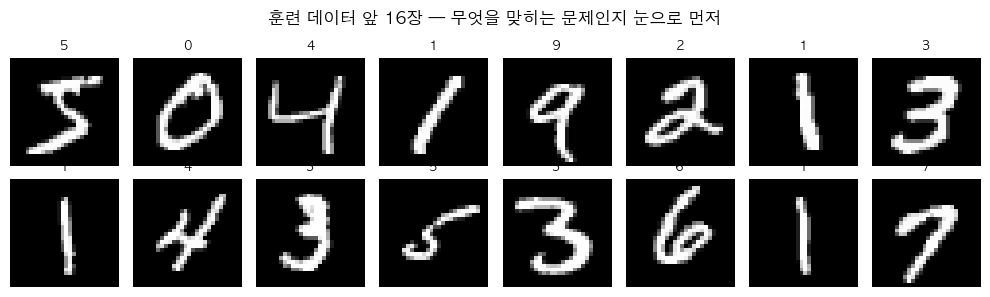

In [8]:
# [Step 1.5] 데이터 확인(EDA) — 학습 전에 데이터부터 본다 (제공)
# 어떤 데이터인지 모르고 모델부터 돌리는 것은 문제를 안 읽고 답부터 쓰는 것과 같습니다.
import numpy as np

print("shape :", x_train.shape, "· dtype:", x_train.dtype)     # (60000, 28, 28) uint8 — 아직 전처리 전
print("값 범위:", x_train.min(), "~", x_train.max())            # 0(검정) ~ 255(흰색)
cls, cnt = np.unique(y_train, return_counts=True)
print("클래스 분포:", dict(zip(cls.tolist(), cnt.tolist())))     # 0~9가 대략 6천 장씩 — 거의 균형
# ↑ 클래스가 균형이므로 '정확도'가 공정한 성적표가 됩니다 (한쪽으로 쏠린 데이터라면 정확도만 봐선 안 됩니다 — 9강 참조)

fig, axes = plt.subplots(2, 8, figsize=(10, 3))
for k, ax in enumerate(axes.flat):
    ax.imshow(x_train[k], cmap="gray")
    ax.set_title(int(y_train[k]), fontsize=9); ax.axis("off")
plt.suptitle("훈련 데이터 앞 16장 — 무엇을 맞히는 문제인지 눈으로 먼저")
plt.tight_layout(); plt.show()

In [9]:
# [Step 2] TODO ① 완료 — CNN 입력 형태로 전처리하고 validation을 분리합니다.
x_train = x_train.reshape(-1, 1, 28, 28).astype("float32") / 255.0
x_test = x_test.reshape(-1, 1, 28, 28).astype("float32") / 255.0

assert x_train.shape == (60000, 1, 28, 28), f"shape가 다릅니다: {x_train.shape}"
assert str(x_train.dtype) == "float32" and x_train.max() <= 1.0, "dtype 또는 값 범위를 확인하세요"

split_idx = np.random.default_rng(0).permutation(len(x_train))
fit_idx, val_idx = split_idx[:-10000], split_idx[-10000:]
x_fit, y_fit = x_train[fit_idx], y_train[fit_idx]
x_val, y_val = x_train[val_idx], y_train[val_idx]
print(f"✅ 전처리·분할 통과: fit {x_fit.shape} / validation {x_val.shape} / test {x_test.shape} (봉인)")

✅ 전처리·분할 통과: fit (50000, 1, 28, 28) / validation (10000, 1, 28, 28) / test (10000, 1, 28, 28) (봉인)


### CNN 모델 — 완성품으로 제공합니다 (단, 손잡이 4개는 여러분 것)

아직 Conv2d의 원리를 배우지 않았으므로(12강), 지금은 **데이터가 흘러가는 shape**만 따라가면 충분합니다:

```
(N, 1, 28, 28) ──Conv2d(1→32)──▶ (N, 32, 28, 28)   32개 필터로 패턴 탐색
              ──MaxPool2d(2)──▶ (N, 32, 14, 14)   절반 크기로 요약
              ──Conv2d(32→64)─▶ (N, 64, 14, 14)   더 복잡한 패턴 64종
              ──MaxPool2d(2)──▶ (N, 64,  7,  7)   다시 절반
              ──Flatten───────▶ (N, 3136)          여기서부터는 3강과 같은 Dense
              ──Linear·Dropout▶ (N, 10)            클래스별 로짓 (softmax 없음)
```

구조는 고정이지만 **크기를 정하는 숫자 4개(`conv1`·`conv2`·`hidden`·`dropout`)는 인자로 열어 두었습니다** — [Step 6]에서 이 손잡이들을 돌려 성능을 탐색하는 것이 이 과제의 본론입니다.

In [10]:
# [Step 3] CNN 모델 — 앱과 동일한 구조
import torch.nn as nn

class CNN(nn.Module):
    def __init__(self, conv1=32, conv2=64, hidden=128, dropout=0.3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, conv1, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(conv1, conv2, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(conv2 * 7 * 7, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 10),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

torch.manual_seed(0)
model = CNN().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"파라미터 수: {n_params:,}")

파라미터 수: 421,642


In [11]:
# [Step 4] TODO ② 완료 — fit 데이터로 훈련
import torch
import torch.nn as nn

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

xt = torch.tensor(x_fit, dtype=torch.float32, device=DEVICE)
yt = torch.tensor(y_fit, dtype=torch.long, device=DEVICE)

EPOCHS = 3
BATCH_SIZE = 128
train_losses = []
for epoch in range(EPOCHS):
    model.train()
    perm = torch.randperm(len(xt), device=DEVICE)
    loss_sum, sample_count = 0.0, 0
    for i in range(0, len(xt), BATCH_SIZE):
        idx = perm[i:i+BATCH_SIZE]
        xb, yb = xt[idx], yt[idx]
        optimizer.zero_grad()
        logits = model(xb)
        loss = loss_fn(logits, yb)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * len(xb)
        sample_count += len(xb)
    train_losses.append(loss_sum / sample_count)
    print(f"epoch {epoch+1}/{EPOCHS} 평균 train loss: {train_losses[-1]:.4f}")

epoch 1/3 평균 train loss: 0.3003
epoch 2/3 평균 train loss: 0.0827
epoch 3/3 평균 train loss: 0.0588


In [12]:
# 추가 학습 — validation 정확도가 더 이상 개선되지 않을 때까지
import copy

import torch
import torch.nn as nn
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=2e-4,
    weight_decay=1e-5,
)

loss_fn = nn.CrossEntropyLoss()

# validation 성능이 정체되면 학습률을 낮춥니다.
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
)

xt = torch.tensor(
    x_fit,
    dtype=torch.float32,
    device=DEVICE,
)

yt = torch.tensor(
    y_fit,
    dtype=torch.long,
    device=DEVICE,
)

xv = torch.tensor(
    x_val,
    dtype=torch.float32,
    device=DEVICE,
)

yv = torch.tensor(
    y_val,
    dtype=torch.long,
    device=DEVICE,
)

BATCH_SIZE = 128
MAX_EXTRA_EPOCHS = 30
EARLY_STOPPING_PATIENCE = 6
MIN_IMPROVEMENT = 0.0001

best_val_acc = 0.0
best_epoch = 0
best_state = copy.deepcopy(model.state_dict())
epochs_without_improvement = 0

for epoch in range(MAX_EXTRA_EPOCHS):
    # 학습
    model.train()
    perm = torch.randperm(len(xt), device=DEVICE)

    total_loss = 0.0
    total_count = 0

    for i in range(0, len(xt), BATCH_SIZE):
        idx = perm[i:i + BATCH_SIZE]
        xb = xt[idx]
        yb = yt[idx]

        optimizer.zero_grad()

        logits = model(xb)
        loss = loss_fn(logits, yb)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(xb)
        total_count += len(xb)

    train_loss = total_loss / total_count

    # validation 평가
    model.eval()

    with torch.inference_mode():
        val_predictions = model(xv).argmax(dim=1)

        val_acc = (
            (val_predictions == yv)
            .float()
            .mean()
            .item()
        )

    # validation 정확도가 정체되면 학습률 감소
    scheduler.step(val_acc)

    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"추가 epoch {epoch + 1:02d}/{MAX_EXTRA_EPOCHS} | "
        f"loss {train_loss:.4f} | "
        f"validation {val_acc:.4f} | "
        f"lr {current_lr:.1e}"
    )

    # 지금까지 가장 좋은 모델 저장
    if val_acc > best_val_acc + MIN_IMPROVEMENT:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        best_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0

        print(f"  ✅ 최고 기록 갱신: {best_val_acc:.4f}")

    else:
        epochs_without_improvement += 1

        print(
            f"  개선 없음: "
            f"{epochs_without_improvement}/"
            f"{EARLY_STOPPING_PATIENCE}"
        )

    # 일정 기간 개선되지 않으면 종료
    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print("⏹️ validation 정확도가 더 이상 개선되지 않아 종료합니다.")
        break

# 가장 높은 validation 정확도를 기록한 모델로 복원
model.load_state_dict(best_state)
model.eval()

val_acc = best_val_acc

print()
print(f"최고 epoch: {best_epoch}")
print(f"최고 validation 정확도: {best_val_acc:.4f}")
print("✅ 최고 성능의 모델 가중치를 복원했습니다.")

추가 epoch 01/30 | loss 0.0376 | validation 0.9881 | lr 2.0e-04
  ✅ 최고 기록 갱신: 0.9881
추가 epoch 02/30 | loss 0.0337 | validation 0.9896 | lr 2.0e-04
  ✅ 최고 기록 갱신: 0.9896
추가 epoch 03/30 | loss 0.0306 | validation 0.9892 | lr 2.0e-04
  개선 없음: 1/6
추가 epoch 04/30 | loss 0.0265 | validation 0.9901 | lr 2.0e-04
  ✅ 최고 기록 갱신: 0.9901
추가 epoch 05/30 | loss 0.0249 | validation 0.9902 | lr 2.0e-04
  개선 없음: 1/6
추가 epoch 06/30 | loss 0.0238 | validation 0.9893 | lr 2.0e-04
  개선 없음: 2/6
추가 epoch 07/30 | loss 0.0210 | validation 0.9906 | lr 2.0e-04
  ✅ 최고 기록 갱신: 0.9906
추가 epoch 08/30 | loss 0.0194 | validation 0.9903 | lr 2.0e-04
  개선 없음: 1/6
추가 epoch 09/30 | loss 0.0184 | validation 0.9906 | lr 2.0e-04
  개선 없음: 2/6
추가 epoch 10/30 | loss 0.0166 | validation 0.9909 | lr 2.0e-04
  ✅ 최고 기록 갱신: 0.9909
추가 epoch 11/30 | loss 0.0157 | validation 0.9901 | lr 2.0e-04
  개선 없음: 1/6
추가 epoch 12/30 | loss 0.0155 | validation 0.9906 | lr 2.0e-04
  개선 없음: 2/6
추가 epoch 13/30 | loss 0.0134 | validation 0.9908 | lr 1.0e-0

In [13]:
# [Step 5] validation 평가 — test는 아직 사용하지 않습니다.
model.eval()
with torch.inference_mode():
    xb = torch.tensor(x_val, dtype=torch.float32, device=DEVICE)
    yb = torch.tensor(y_val, dtype=torch.long, device=DEVICE)
    val_acc = (model(xb).argmax(1) == yb).float().mean().item()
print(f"CNN validation 정확도: {val_acc:.4f}")

DENSE_VAL_ACC = None
if DENSE_VAL_ACC is not None:
    print(f"Dense 대비: {DENSE_VAL_ACC:.4f} → {val_acc:.4f} ({(val_acc-DENSE_VAL_ACC)*100:+.2f}%p)")

CNN validation 정확도: 0.9916


### [Step 6] 손잡이 탐색 실험 — validation으로 3개

test를 보지 않고, 기준 모델에서 한 번에 한 손잡이만 바꿉니다.

| 실험 | 바꾼 것 | 가설 | 다음 판단 |
|---|---|---|---|
| 기준 | 기본값·3 epochs | 비교 기준 | validation 결과 기록 |
| 실험 1 | epochs 3→8 | 더 학습하면 획 특징을 안정적으로 배워 99% 이상에 도달할 것 | 향상 시 더 긴 학습 채택 |
| 실험 2 | dropout 0.3→0.5 | 규제를 강화하면 일반화가 좋아질 수 있음 | 하락 시 과도한 규제로 판단 |
| 실험 3 | hidden 128→256 | 분류부 용량 증가로 복잡한 패턴 구분 가능 | 성능 대비 파라미터 증가 비교 |

아래 실행 결과 표에서 validation 정확도와 파라미터 수를 비교해 최고 모델을 선택합니다.

In [14]:
# [Step 6] TODO ④ 완료 — validation 실험 3개
import time
import pandas as pd

def run_cnn(x_tr, y_tr, x_va, y_va, conv1=32, conv2=64, hidden=128,
            dropout=0.3, lr=1e-3, epochs=3, batch=128, seed=0):
    torch.manual_seed(seed)
    m = CNN(conv1, conv2, hidden, dropout).to(DEVICE)
    opt = torch.optim.Adam(m.parameters(), lr=lr)
    xt_ = torch.tensor(x_tr, dtype=torch.float32, device=DEVICE)
    yt_ = torch.tensor(y_tr, dtype=torch.long, device=DEVICE)
    t0, losses = time.time(), []
    for ep in range(epochs):
        m.train()
        perm = torch.randperm(len(xt_), device=DEVICE)
        loss_sum, sample_count = 0.0, 0
        for i in range(0, len(xt_), batch):
            idx = perm[i:i+batch]
            opt.zero_grad()
            loss = loss_fn(m(xt_[idx]), yt_[idx])
            loss.backward()
            opt.step()
            loss_sum += loss.item() * len(idx)
            sample_count += len(idx)
        losses.append(loss_sum / sample_count)
    m.eval()
    with torch.inference_mode():
        xb_ = torch.tensor(x_va, dtype=torch.float32, device=DEVICE)
        yb_ = torch.tensor(y_va, dtype=torch.long, device=DEVICE)
        val_acc_ = (m(xb_).argmax(1) == yb_).float().mean().item()
    n = sum(p.numel() for p in m.parameters())
    print(f"val acc {val_acc_:.4f} · loss {losses[-1]:.4f} · 파라미터 {n:,} · {time.time()-t0:.0f}초"
          f" ← conv {conv1}/{conv2} · hidden {hidden} · dropout {dropout} · lr {lr} · epochs {epochs}")
    return m, val_acc_, losses

candidate1, val1, losses1 = run_cnn(x_fit, y_fit, x_val, y_val, epochs=8)
candidate2, val2, losses2 = run_cnn(x_fit, y_fit, x_val, y_val, dropout=0.5)
candidate3, val3, losses3 = run_cnn(x_fit, y_fit, x_val, y_val, hidden=256)

experiment_results = pd.DataFrame([
    {"실험":"기준", "변경":"없음", "validation 정확도":val_acc, "파라미터":n_params},
    {"실험":"실험 1", "변경":"epochs=8", "validation 정확도":val1, "파라미터":sum(p.numel() for p in candidate1.parameters())},
    {"실험":"실험 2", "변경":"dropout=0.5", "validation 정확도":val2, "파라미터":sum(p.numel() for p in candidate2.parameters())},
    {"실험":"실험 3", "변경":"hidden=256", "validation 정확도":val3, "파라미터":sum(p.numel() for p in candidate3.parameters())},
])
display(experiment_results.style.format({"validation 정확도":"{:.4f}", "파라미터":"{:,}"}))

val acc 0.9898 · loss 0.0242 · 파라미터 421,642 · 17초 ← conv 32/64 · hidden 128 · dropout 0.3 · lr 0.001 · epochs 8
val acc 0.9857 · loss 0.0838 · 파라미터 421,642 · 7초 ← conv 32/64 · hidden 128 · dropout 0.5 · lr 0.001 · epochs 3
val acc 0.9885 · loss 0.0489 · 파라미터 824,458 · 7초 ← conv 32/64 · hidden 256 · dropout 0.3 · lr 0.001 · epochs 3


,실험,변경,validation 정확도,파라미터
0,기준,없음,0.9916,"421,642"
1,실험 1,epochs=8,0.9898,"421,642"
2,실험 2,dropout=0.5,0.9857,"421,642"
3,실험 3,hidden=256,0.9885,"824,458"


In [15]:
# [Step 7] validation 최고 모델 확정 → test 1회 → 체크포인트 저장
candidates = [
    ("기준", model, val_acc, train_losses,
     {"conv1":32, "conv2":64, "hidden":128, "dropout":0.3, "epochs":3, "lr":1e-3, "batch":128}),
    ("epochs=8", candidate1, val1, losses1,
     {"conv1":32, "conv2":64, "hidden":128, "dropout":0.3, "epochs":8, "lr":1e-3, "batch":128}),
    ("dropout=0.5", candidate2, val2, losses2,
     {"conv1":32, "conv2":64, "hidden":128, "dropout":0.5, "epochs":3, "lr":1e-3, "batch":128}),
    ("hidden=256", candidate3, val3, losses3,
     {"conv1":32, "conv2":64, "hidden":256, "dropout":0.3, "epochs":3, "lr":1e-3, "batch":128}),
]
BEST_NAME, best_model, BEST_VAL_ACC, BEST_LOSSES, BEST_CONFIG = max(candidates, key=lambda item: item[2])
print(f"validation으로 선택한 설정: {BEST_NAME} ({BEST_VAL_ACC:.4f})")

# 설정 선택이 끝났으므로 여기서 test를 딱 한 번 평가합니다.
best_model.eval()
with torch.inference_mode():
    test_x = torch.tensor(x_test, dtype=torch.float32, device=DEVICE)
    test_y = torch.tensor(y_test, dtype=torch.long, device=DEVICE)
    test_pred = best_model(test_x).argmax(1)
    FINAL_TEST_ACC = (test_pred == test_y).float().mean().item()

from pathlib import Path
app_dir = Path("과제_Streamlit_앱_분류")
app_dir.mkdir(exist_ok=True)
best_model = best_model.to("cpu")
checkpoint = {
    "state_dict": best_model.state_dict(),
    "model_config": {k: BEST_CONFIG[k] for k in ["conv1", "conv2", "hidden", "dropout"]},
    "training_config": {k: BEST_CONFIG[k] for k in ["epochs", "lr", "batch"]},
    "metrics": {"val_acc": BEST_VAL_ACC, "test_acc": FINAL_TEST_ACC},
    "n_params": sum(p.numel() for p in best_model.parameters()),
}
torch.save(checkpoint, app_dir / "mnist_cnn.pt")
print(f"최종 확정: validation {BEST_VAL_ACC:.4f} · test {FINAL_TEST_ACC:.4f} (test 1회)")
print(f"저장 완료: {app_dir / 'mnist_cnn.pt'}")

validation으로 선택한 설정: 기준 (0.9916)
최종 확정: validation 0.9916 · test 0.9920 (test 1회)
저장 완료: 과제_Streamlit_앱_분류/mnist_cnn.pt


## ✅ 1차 과제 완료 — 제출 방법과 최소 기준

1. [Step 1]~[Step 7] 전부 실행하고 결과를 남깁니다.
2. 아래 제출용 그래프 2종을 실행합니다.
3. 노트북·앱 URL·리더보드 1행을 제출합니다.

| 기준 | 통과선 |
|---|---|
| TODO ①~④ 완성 | 자리표시(`...`) 잔존 0 |
| validation 정확도 | **0.9850 이상** |
| 손잡이 탐색 | validation 실험 **3개 이상** + 가설·결과·다음 수 |
| 최종 test | 최고 설정 확정 뒤 **1회만** 평가 — 목표 **0.99 이상** |
| 제출용 그래프 | 학습 곡선 + validation 실험 비교 |

목표: validation **0.9850 이상**(통과)을 확보한 뒤, 최종 test **0.99 이상**에 도전하세요. test는 순위를 위한 최종 성적표이지 손잡이 탐색 도구가 아닙니다.


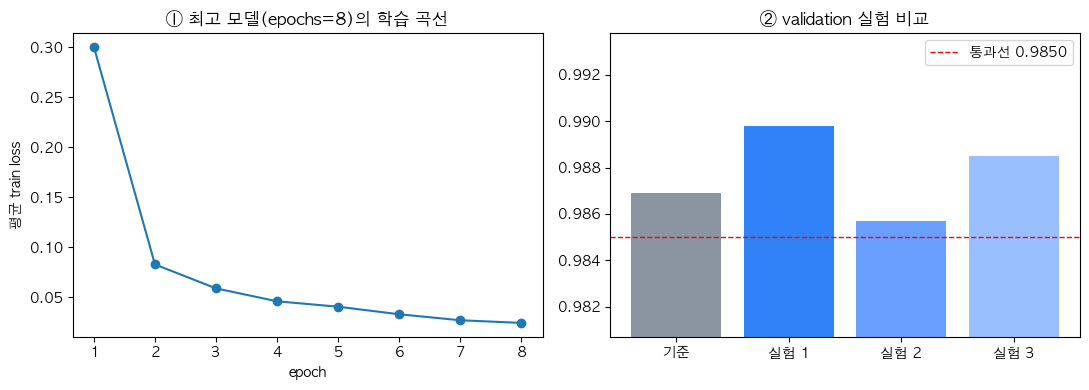

In [10]:
# [1차 제출물] 학습 곡선 + validation 실험 비교
best_losses = BEST_LOSSES
my_results = dict(zip(experiment_results["실험"], experiment_results["validation 정확도"]))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(range(1, len(best_losses) + 1), best_losses, marker="o")
ax1.set_xlabel("epoch"); ax1.set_ylabel("평균 train loss")
ax1.set_title(f"① 최고 모델({BEST_NAME})의 학습 곡선")
names, accs = list(my_results.keys()), list(my_results.values())
ax2.bar(names, accs, color=["#8b95a1", "#3182f6", "#6b9fff", "#9abfff"])
ax2.axhline(0.9850, ls="--", c="red", lw=1, label="통과선 0.9850")
ax2.set_ylim(min(accs) - 0.005, max(accs) + 0.004)
ax2.set_title("② validation 실험 비교"); ax2.legend()
plt.tight_layout(); plt.show()

## 2차 과제 (필수) — Fashion-MNIST: 같은 코드, 다른 문제

`keras.datasets.fashion_mnist`는 MNIST와 **완전히 같은 형식**(28×28 흑백, 10클래스, 60,000+10,000장)의 의류 이미지입니다. **데이터 로드는 아래 셀에 제공했습니다** — 이후 전 과정을 여러분이 재현합니다.

끝나면 아래 3가지 질문에 답을 적으세요 (마크다운 셀 추가):

1. MNIST보다 정확도가 얼마나 떨어졌나요? **왜** 떨어졌을까요?
2. 오답을 시각화하면 어떤 클래스끼리 헷갈리나요? (3강 [답안지 열람] 셀 재사용)
3. 새 모델로 다시 시작하지 않고 MNIST로 학습한 모델을 이어서 쓰면 안 되는 이유는?

훈련 원본: (60000, 28, 28), 최종 test: (10000, 28, 28)
클래스 분포: {'티셔츠': 6000, '바지': 6000, '풀오버': 6000, '드레스': 6000, '코트': 6000, '샌들': 6000, '셔츠': 6000, '스니커즈': 6000, '가방': 6000, '앵클부츠': 6000}


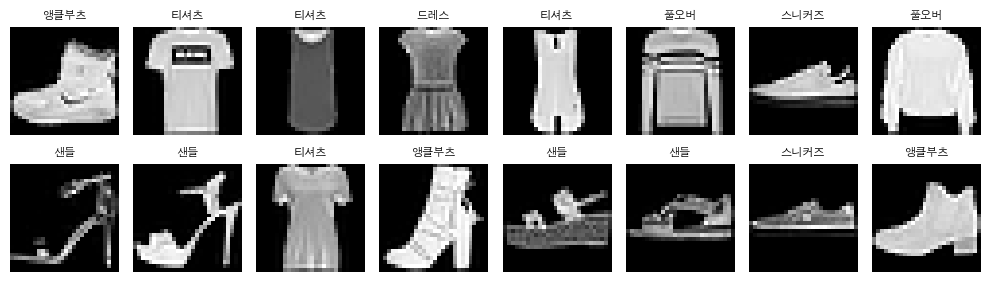

val acc 0.8959 · loss 0.3080 · 파라미터 421,642 · 7초 ← conv 32/64 · hidden 128 · dropout 0.3 · lr 0.001 · epochs 3


val acc 0.9069 · loss 0.2537 · 파라미터 421,642 · 12초 ← conv 32/64 · hidden 128 · dropout 0.3 · lr 0.001 · epochs 5
Fashion validation 선택: epochs=5 (0.9069)
Fashion-MNIST 최종 test 정확도: 0.9025 (test 1회)


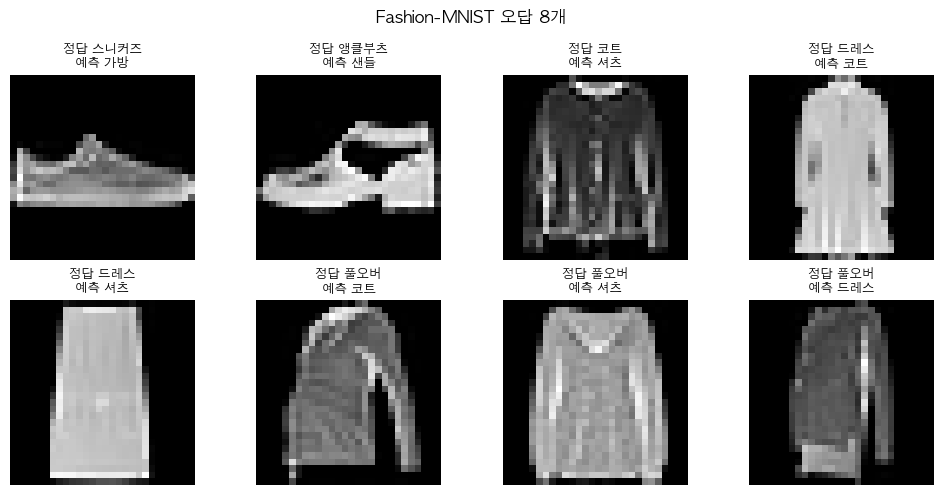

In [11]:
# [Step 8] TODO ⑤ 완료 — Fashion-MNIST 별도 validation + test 1회 + 오답 확인
class_names = ["티셔츠","바지","풀오버","드레스","코트","샌들","셔츠","스니커즈","가방","앵클부츠"]
(fx_train, fy_train), (fx_test, fy_test) = keras.datasets.fashion_mnist.load_data()
print(f"훈련 원본: {fx_train.shape}, 최종 test: {fx_test.shape}")

fcls, fcnt = np.unique(fy_train, return_counts=True)
print("클래스 분포:", {class_names[c]: int(n) for c, n in zip(fcls, fcnt)})
fig, axes = plt.subplots(2, 8, figsize=(10, 3))
for k, ax in enumerate(axes.flat):
    ax.imshow(fx_train[k], cmap="gray")
    ax.set_title(class_names[fy_train[k]], fontsize=8); ax.axis("off")
plt.tight_layout(); plt.show()

# MNIST와 같은 입력 계약
fx_train = fx_train.reshape(-1, 1, 28, 28).astype("float32") / 255.0
fx_test = fx_test.reshape(-1, 1, 28, 28).astype("float32") / 255.0
fidx = np.random.default_rng(0).permutation(len(fx_train))
ffit_idx, fval_idx = fidx[:-10000], fidx[-10000:]
fx_fit, fy_fit = fx_train[ffit_idx], fy_train[ffit_idx]
fx_val, fy_val = fx_train[fval_idx], fy_train[fval_idx]

# 별도 validation 실험: 기준 3 epochs와 epochs=5 비교
fashion_base, fashion_val, fashion_losses = run_cnn(fx_fit, fy_fit, fx_val, fy_val, epochs=3)
fashion_long, fashion_long_val, fashion_long_losses = run_cnn(fx_fit, fy_fit, fx_val, fy_val, epochs=5)
if fashion_long_val > fashion_val:
    fashion_best, fashion_best_val = fashion_long, fashion_long_val
    fashion_best_name, fashion_best_losses = "epochs=5", fashion_long_losses
else:
    fashion_best, fashion_best_val = fashion_base, fashion_val
    fashion_best_name, fashion_best_losses = "기준 epochs=3", fashion_losses
print(f"Fashion validation 선택: {fashion_best_name} ({fashion_best_val:.4f})")

# validation으로 선택을 끝낸 뒤 Fashion test도 딱 한 번 평가
fashion_best.eval()
with torch.inference_mode():
    fashion_test_pred = fashion_best(
        torch.tensor(fx_test, dtype=torch.float32, device=DEVICE)
    ).argmax(1).cpu().numpy()
fashion_test_acc = float((fashion_test_pred == fy_test).mean())
print(f"Fashion-MNIST 최종 test 정확도: {fashion_test_acc:.4f} (test 1회)")

# 오답 8개 시각화
wrong = np.flatnonzero(fashion_test_pred != fy_test)[:8]
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for idx, ax in zip(wrong, axes.flat):
    ax.imshow(fx_test[idx, 0], cmap="gray")
    title = "정답 " + class_names[fy_test[idx]] + chr(10) + "예측 " + class_names[fashion_test_pred[idx]]
    ax.set_title(title, fontsize=9)
    ax.axis("off")
plt.suptitle("Fashion-MNIST 오답 8개")
plt.tight_layout(); plt.show()

> 🏅 **[도전/심화]** — 아래는 **선택** 과제입니다. 필수 제출 범위가 아니며, 더 파고들고 싶은 사람만 진행하세요. (CPU에서는 학습이 오래 걸립니다 — Colab GPU 권장)

In [ ]:
# 🏅 [도전] CIFAR-10 — 컬러 이미지(3채널)로 확장
# CIFAR-10: 32×32 '컬러' 이미지 10클래스 (비행기·자동차·새·고양이·사슴·개·개구리·말·배·트럭)
import os
os.environ.setdefault("KERAS_BACKEND", "torch")
import keras
(cx_train, cy_train), (cx_test, cy_test) = keras.datasets.cifar10.load_data()
print(cx_train.shape)   # (50000, 32, 32, 3) ← 마지막 3이 컬러 채널(RGB)

# 도전 포인트 — 스스로 해결해보세요:
# ① 전처리: keras는 (N, 높이, 너비, 채널) 순서, PyTorch Conv2d는 (N, 채널, 높이, 너비) 순서입니다.
#    힌트: x.transpose(0, 3, 1, 2)
# ② 모델: CNN 클래스를 복사해 CIFAR용으로 수정하세요 — 첫 Conv2d의 입력 채널 1을 3으로 바꾸면...
#    Linear 크기에서 에러가 납니다. 왜일까요?
#    힌트: 32×32는 MaxPool 두 번 뒤 8×8이 됩니다. conv2 * 7 * 7이 어떻게 바뀌어야 할까요?
#    (에러 메시지가 정확한 숫자를 알려줍니다)
# ③ 정답 라벨: cy_train의 shape가 (50000, 1)입니다 — .ravel()로 (50000,)을 만들어야 합니다.


## 3차 과제 (필수) — 분류 Streamlit 앱의 핵심 연결 완성

Part I `수강생배포_Streamlit특강`의 원칙처럼 **학습 코드와 보여주는 화면을 분리**합니다. 다만 `app.py`는 완성 답안이 아닙니다. 화면·오류 안내·사진 정렬 보조 함수는 제공하고, 모델을 실제 예측으로 연결하는 핵심은 직접 작성합니다.

```text
과제_Streamlit_앱_분류/
├─ app.py              ← TODO 1~4 직접 완성
├─ requirements.txt
├─ 배포_가이드.md
└─ mnist_cnn.pt        ← [Step 7]이 생성
```

직접 완성할 네 가지:

1. 학습 때와 같은 `CNN` 구조와 `forward`
2. `model_config`·`state_dict`로 모델 복원 후 `eval()`
3. 28×28 배열을 `(1,1,28,28)` float32 0~1 tensor로 변환
4. `inference_mode`에서 logit을 확률로 변환

```bash
cd 과제_Streamlit_앱_분류
python3.11 -m pip install -r requirements.txt
python3.11 -m streamlit run app.py
```

TODO를 순서대로 완성하면 앱이 다음 점검 지점을 알려줍니다. 정답 한 줄을 옮기는 과제가 아니라, 노트북의 모델·입력 계약을 앱에 다시 연결하는 과제입니다.

### 최종 통합 — 회귀 프로젝트까지 마친 뒤 showcase에 연결

분류 앱은 나중에 회귀 앱과 하나의 포트폴리오로 연결됩니다. 미니프로젝트 2까지 완료한 뒤 `showcase/profile.py`에 내 결과와 한계를 작성하고 아래 명령으로 실행합니다.

```bash
cd 미니프로젝트
python3.11 -m streamlit run showcase/Home.py
```

Part I showcase와 같은 단방향 구조입니다. `showcase`가 두 앱을 재사용하며, 두 앱은 각각 독립 실행도 가능합니다. 최종 권장 제출은 Home·분류·회귀가 함께 열리는 showcase URL 하나입니다.

## 🏆 우리 반 리더보드 — test는 최종 1회 기록만

**모델 선택은 validation, 리더보드 제출은 최종 test**입니다. test를 본 뒤 다시 학습 설정을 바꾸면 공정한 비교가 아니므로 재제출 사유와 변경 내용을 함께 적습니다.

| 트랙 | 모델 선택 기준 | 최종 test 목표 |
|---|---|---|
| ✍️ MNIST | validation 실험으로 직접 선택 | **0.99 이상** |
| 👕 Fashion | 내 validation 실험값으로 선택 | 선택 모델의 test 1회 기록 |

| 부문 | 규칙 |
|---|---|
| 🎯 정확도 | validation으로 고른 모델의 최종 test 정확도 |
| 🪶 경량 | 파라미터 150,000개 이하 중 최종 test 정확도 |
| 📷 실사용 | 같은 손글씨 이미지를 여러 앱에 올리고 분포 차이를 설명 |

| 이름 | 앱 URL | MNIST val/test | Fashion val/test | 파라미터 수 | 내 최고의 한 수 | 한 줄 소감 |
|---|---|---|---|---|---|---|
| (예) 홍길동 | https://...streamlit.app | 0.98xx / 0.99xx | ... / ... | 421,642 | epochs 조정 | 촬영 사진에서는 중심 정렬이 중요했다 |


## 3️⃣ Debug — 흔한 오류

| # | 증상 | 힌트 |
|---|---|---|
| 1 | Conv2d가 `[128, 784]` 입력을 거부 | 입력 계약은 `(N,1,28,28)`입니다 |
| 2 | 앱에서 체크포인트 키 또는 shape 오류 | [Step 7]의 새 딕셔너리 체크포인트를 사용했나요? |
| 3 | Cloud 설치 실패 | 제공된 최소 `requirements.txt`를 저장소 루트에 올렸나요? |
| 4 | 촬영 이미지 예측이 엉뚱함 | 앱에 표시되는 28×28 전처리 미리보기에서 숫자가 중앙·흰색인지 확인하세요 |
| 5 | MPS float64 오류 | `.astype("float32") / 255.0` 순서를 유지하세요 |


## 2️⃣ Review — 내 과제 코드를 AI에게 리뷰받기

제출 전에 아래 셀로 내 코드(특히 TODO로 채운 부분)를 리뷰받아 보세요. 리뷰 결과 중 동의하는 것만 반영하면 됩니다.

In [ ]:
# ── 2️⃣ Review (코드형) — 로컬/클라우드 LLM에게 내 코드·판단을 리뷰받기 ──
# [사전조건] 로컬: LM Studio(00-1)/Ollama(00-2) 서버 실행  |  클라우드: OPENROUTER/OPENAI 키 설정
# openai 패키지가 없으면 아래 주석을 풀어 한 번만 실행하세요 (이미 있으면 건너뛰기)
# !pip install openai
import os
from openai import OpenAI

PROVIDER = "lmstudio"   # "lmstudio" | "ollama" | "openrouter" | "openai"  ← 한 줄만 바꾸면 전환
PROVIDERS = {
    "lmstudio":   {"base_url": "http://localhost:1234/v1",  "model": "local-model",          "api_key": "lm-studio"},
    "ollama":     {"base_url": "http://localhost:11434/v1", "model": "qwen2.5-coder:latest", "api_key": "ollama"},
    "openrouter": {"base_url": "https://openrouter.ai/api/v1", "model": "google/gemma-4-26b-a4b-it:free", "api_key": os.getenv("OPENROUTER_API_KEY", "")},
    "openai":     {"base_url": None, "model": "gpt-4o-mini", "api_key": os.getenv("OPENAI_API_KEY", "")},
}

# 이 과제의 리뷰 프롬프트
REVIEW_PROMPT = """딥러닝 입문 과제(MNIST를 CNN으로 분류)를 제출하기 전이야. 내가 작성한 아래 코드를 리뷰해줘 —
① fit/validation/test가 분리됐고 모델 선택 전 test를 쓰지 않았는지 ② 전처리가 (N,1,28,28) float32 0~1 계약을 지키는지
③ 훈련 5단계 순서가 맞는지 ④ 손잡이 탐색이 시드 고정·새 모델·한 번에 하나만 변경 원칙을 지키는지 ⑤ 로짓 softmax 중복·train/eval 누락이 없는지.
잘한 점, 고칠 점, 근거를 나눠서 답해줘.

=== 내 코드 ===
(여기에 TODO로 채운 셀들을 붙여넣으세요)
==================="""

cfg = PROVIDERS[PROVIDER]
client = OpenAI(base_url=cfg["base_url"], api_key=cfg["api_key"] or "none")
try:
    r = client.chat.completions.create(
        model=cfg["model"], temperature=0.7, max_tokens=2000,
        messages=[
            {"role": "system", "content": "당신은 파이썬·딥러닝을 가르치는 멘토입니다. 정답을 바로 주지 말고 근거와 함께 리뷰하세요."},
            {"role": "user", "content": REVIEW_PROMPT},
        ],
    )
    ans = (r.choices[0].message.content or "").strip()
    print(ans if ans else "⚠️ 빈 답변 — 추론 모델이 max_tokens를 소진했을 수 있습니다(max_tokens↑ 또는 비추론 모델).")
except Exception as e:
    print(f"⚠️ LLM 연결 실패: {e}\n→ 로컬 서버(LM Studio/Ollama) 실행 여부와 PROVIDER 설정을 확인하세요.")

---
## ✅ 제출 체크리스트

- [ ] TODO ①~⑤ · ✍️ 직접 입력을 완성하고 실행 결과 저장
- [ ] MNIST validation 실험 3개 이상 + Fashion 추가 실험 1개 이상
- [ ] 각 트랙의 설정을 validation으로 확정한 뒤 test 1회만 평가
- [ ] 학습 곡선·validation 비교 그래프와 Fashion 오답 이미지 포함
- [ ] 분류 앱 TODO 1~4 완성 + 업로드·촬영·예측·사이드바 지표 확인
- [ ] 회귀 프로젝트 완료 뒤 통합 showcase의 분류 페이지 연결 확인
- [ ] 리더보드 1행 작성

## 📚 [세션 요약]

> 1. fit은 가중치를 배우고, validation은 설정을 고르며, test는 마지막 성적표입니다.
> 2. Dense든 CNN이든 훈련 5단계는 같고 입력 shape과 모델 구조가 달라집니다.
> 3. test 정확도가 높아도 촬영 이미지의 배경·크기·중심이 다르면 실사용 성능은 낮아질 수 있습니다.
>
> ➡️ 다음: 미니프로젝트 2(시간 순서를 지키는 서울 자전거 수요 회귀)
